# QTagger+ — Full-Scale CTGAN Retrain for 5-Class Malware Family Balancing
**CIC-MalMem-2022 | Kaggle GPU notebook**

This notebook does four things end to end:

1. Loads `MalMem2022.csv` and derives the **malware family** label (`Benign`, `Ransomware`, `Trojan`, `Spyware` — **`Worm` is not present in CIC-MalMem-2022**, a known dataset gap, see note below).
2. Reconfigures **CTGAN for a full-scale retrain**: 300+ epochs per minority class, **no 1,500-row cap** (uses the *full* real row count for every class), with **generator/discriminator loss logging every epoch** and **mid-run checkpointing** so mode collapse is caught early and training survives a Kaggle session crash.
3. Balances `Ransomware`, `Trojan`, and `Spyware` up to the `Benign` count using the trained CTGAN generators, then benchmarks classifiers (Random Forest, XGBoost, LightGBM) for maximum macro-F1 on a **held-out, 100% real** test set.
4. Is written specifically for **Kaggle's runtime constraints** (single GPU, ~9–12 h session wall-clock, ~30 GPU-h/week quota, working-dir persistence rules) — every long-running cell is resumable.

> **If your Kaggle session crashes or you run out of GPU quota:** see the "Crash recovery" markdown cell near the bottom before re-running anything. Short version — just re-run the notebook top to bottom; every checkpointed cell detects existing progress and continues instead of restarting.


## 0. Kaggle environment & constraints check

Kaggle GPU notebooks (P100 or T4x2) currently give you:
- **~9–12 hours per interactive session** before a forced disconnect.
- **~30 GPU-hours/week** quota (resets weekly) — training 3 classes × 300+ epochs will burn real quota, so this notebook chunks training and checkpoints so you can spread it across multiple sessions/days if needed.
- `/kaggle/working` **persists across a crash/restart of the same kernel** (a crash kills the process, not the disk) — it is wiped only if you do a "Factory reset" or start a brand-new kernel. That's why every checkpoint below is written there.
- If you're on the **free/interactive tier**, closing the browser tab does *not* stop the kernel, but hitting the weekly quota does — the cell below tells you where you stand.


In [1]:

import os, sys, subprocess, time, json

IS_KAGGLE = os.path.exists('/kaggle/input')
WORK_DIR = '/kaggle/working' if IS_KAGGLE else '/home/claude/work'
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(f'{WORK_DIR}/ctgan_checkpoints', exist_ok=True)
os.makedirs(f'{WORK_DIR}/logs', exist_ok=True)
os.makedirs(f'{WORK_DIR}/models', exist_ok=True)

print(f"Running on Kaggle: {IS_KAGGLE}")
print(f"Working directory: {WORK_DIR}")

# GPU check
try:
    print(subprocess.check_output(['nvidia-smi', '--query-gpu=name,memory.total,memory.used',
                                    '--format=csv']).decode())
except Exception as e:
    print("nvidia-smi not available (no GPU attached?):", e)

import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))

# --- session time budget tracker ---------------------------------------------------
SESSION_START = time.time()
SESSION_TIME_BUDGET_HOURS = 8.5  # stay safely under Kaggle's ~9-12h hard limit
def time_left_hours():
    return SESSION_TIME_BUDGET_HOURS - (time.time() - SESSION_START) / 3600

def time_budget_ok(min_hours_needed=0.25):
    left = time_left_hours()
    if left < min_hours_needed:
        print(f"⚠️  Only {left:.2f}h left in the safe session budget — stopping this stage "
              f"cleanly so checkpoints are saved. Re-run this notebook to resume.")
        return False
    return True


Running on Kaggle: True
Working directory: /kaggle/working
name, memory.total [MiB], memory.used [MiB]
Tesla T4, 15360 MiB, 0 MiB
Tesla T4, 15360 MiB, 0 MiB

CUDA available: True
GPU: Tesla T4
VRAM (GB): 15.6


In [2]:
import sys
import site
import subprocess
import importlib

# Install packages into the current Python environment
subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "ctgan==0.10.2",
    "imbalanced-learn",
    "xgboost",
    "lightgbm",
    "scipy"
])

# Refresh Python's import cache
importlib.invalidate_caches()

# Add any newly created site-packages directories
for p in site.getsitepackages():
    if p not in sys.path:
        sys.path.append(p)

try:
    import ctgan
    print("CTGAN version:", ctgan.__version__)
except Exception as e:
    print("Import still failed:", e)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 10.3 MB/s eta 0:00:00
CTGAN version: 0.10.2


## 1. Load data

In [3]:
import os
import pandas as pd
import numpy as np

CANDIDATE_PATHS = [
    '/kaggle/input/datasets/shanmukhadattaboda/cic-malmem-dataset/MalMem2022.csv',
    '/kaggle/input/datasets/shanmukhadattaboda/cic-malmem-dataset/MalMem2022.csv',
    '/mnt/user-data/uploads/MalMem2022__1_.csv',   # local fallback (this session)
    'MalMem2022.csv',
]
DATA_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Couldn't find MalMem2022.csv. On Kaggle, add the CIC-MalMem-2022 dataset via "
        "'+ Add Input' and update CANDIDATE_PATHS with the exact path shown there."
    )

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
df.head()


Loaded: /kaggle/input/datasets/shanmukhadattaboda/cic-malmem-dataset/MalMem2022.csv
Shape: (58596, 58)


,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,...,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class,Category,Filename
0,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,0,...,24,116,0,121,87,0,8,Benign,Benign,Benign
1,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,0,...,24,118,0,122,87,0,8,Benign,Benign,Benign
2,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,0,...,27,118,0,120,88,0,8,Benign,Benign,Benign
3,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,0,...,27,118,0,120,88,0,8,Benign,Benign,Benign
4,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,0,...,24,118,0,124,87,0,8,Benign,Benign,Benign


In [4]:
# ==========================================================
# Restore previous CTGAN checkpoints from Kaggle Input
# Run this BEFORE the CTGAN training cell
# ==========================================================

import os
import shutil

# <<< CHANGE THIS >>>
INPUT_DIR = "/kaggle/input/notebooks/shanmukhadattaboda/ctgan-retrianing"   # <-- your Kaggle Input dataset

SRC = os.path.join(INPUT_DIR, "ctgan_checkpoints")
DST = "/kaggle/working/ctgan_checkpoints"

os.makedirs(DST, exist_ok=True)

if os.path.exists(SRC):
    for f in os.listdir(SRC):
        shutil.copy2(
            os.path.join(SRC, f),
            os.path.join(DST, f)
        )
    print("✓ Previous CTGAN checkpoints restored.")
else:
    print("⚠ No checkpoint folder found.")

✓ Previous CTGAN checkpoints restored.


## 2. Derive the 5-class family label

`Category` in this dataset is fine-grained (e.g. `Ransomware-Ako`, `Trojan-Zeus`). The **family**
label QTagger+ targets is the prefix before the dash. Family-level counts:

| Family | Rows |
|---|---|
| Benign | 29,298 |
| Spyware | 10,020 |
| Ransomware | 9,791 |
| Trojan | 9,487 |
| **Worm** | **0 — not present in CIC-MalMem-2022** |

**Open issue carried over from Week 1:** CIC-MalMem-2022 simply has no Worm samples, so a true
5-class classifier can't be trained/evaluated on this dataset alone. Two honest options:
1. Ship the model as **4-class** (Benign/Ransomware/Trojan/Spyware) and document the Worm gap.
2. Source Worm samples from another memory-dump corpus (e.g. a subset of EMBER-adjacent memory
   captures or a separate worm sandbox run) and fold them in with matching features — this is a
   data-acquisition task, not something CTGAN can synthesize from zero real Worm rows (CTGAN
   models the distribution of *existing* data — it cannot invent a class it has never seen).

This notebook proceeds with the 4 real classes and clearly labels the Worm gap wherever it's
relevant (EMBER-2018 cross-generalization is the natural place to test whether extending to
Worm is even feasible with transferred features).


In [5]:

df['Family'] = df['Category'].apply(lambda c: c.split('-')[0])
print(df['Family'].value_counts())

FEATURE_COLS = [c for c in df.columns if c not in ('Class', 'Category', 'Filename', 'Family')]
print(f"\n{len(FEATURE_COLS)} numeric features")
assert df[FEATURE_COLS].isnull().sum().sum() == 0, "Unexpected nulls in feature columns"


Family
Benign        29298
Spyware       10020
Ransomware     9791
Trojan         9487
Name: count, dtype: int64

55 numeric features


## 3. Stratified train/test split — test set stays 100% real, untouched by any synthetic data

In [6]:

from sklearn.model_selection import train_test_split

X = df[FEATURE_COLS].copy()
y = df['Family'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

train_df = X_train.copy()
train_df['Family'] = y_train.values

print("Train family counts:")
print(train_df['Family'].value_counts())
print("\nTest family counts (held out, real-only, never touched by CTGAN):")
print(y_test.value_counts())

BENIGN_TRAIN_COUNT = (train_df['Family'] == 'Benign').sum()
print(f"\nBalancing target for every minority family: {BENIGN_TRAIN_COUNT} rows (= Benign train count)")


Train family counts:
Family
Benign        23438
Spyware        8016
Ransomware     7833
Trojan         7589
Name: count, dtype: int64

Test family counts (held out, real-only, never touched by CTGAN):
Family
Benign        5860
Spyware       2004
Ransomware    1958
Trojan        1898
Name: count, dtype: int64

Balancing target for every minority family: 23438 rows (= Benign train count)


## 4. Full-scale CTGAN — the reconfiguration you asked for

Changes vs. the Week-1 capped run:

| Setting | Week 1 (capped) | This run |
|---|---|---|
| Rows fed to CTGAN per class | capped at 1,500 | **all real rows for that class** (no cap) |
| Epochs | ~100 or fewer | **300+ (configurable, default 320)** |
| Loss visibility | end-of-run summary only | **G/D loss appended to CSV every single epoch, live** |
| Fault tolerance | none — restart from epoch 0 | **checkpoint every N epochs; auto-resumes from last checkpoint** |
| Mode-collapse detection | none | **per-epoch synthetic-batch std-dev tracked; flags collapse automatically** |

### Why a custom subclass instead of just calling `CTGAN(epochs=300).fit(data)`
The stock `ctgan` library's `.fit()` re-initializes the generator, discriminator, and optimizers
*every time it's called* — so simply calling `.fit()` again after a crash restarts training from
random weights, silently throwing away all prior progress. `ResumableCTGAN` below patches this:
it keeps the generator/discriminator alive on `self`, can **warm-start from a saved checkpoint**,
and writes progress to disk incrementally so a Kaggle disconnect never costs you more than
`checkpoint_every` epochs of work.


In [7]:

import torch
import pickle
from torch import optim
from ctgan import CTGAN
from ctgan.synthesizers.ctgan import Generator, Discriminator
from ctgan.data_transformer import DataTransformer
from ctgan.data_sampler import DataSampler


class ResumableCTGAN(CTGAN):
    '''CTGAN with mid-run checkpointing, streaming loss logs, and true resume-from-crash.

    Behavioural differences from stock CTGAN.fit():
      * If `self._generator` already exists (loaded from a checkpoint), training continues
        from those weights instead of re-initializing.
      * Every `checkpoint_every` epochs (and at the final epoch) the full model is pickled
        to `checkpoint_path`, and every SINGLE epoch a loss/collapse row is appended to
        `loss_log_path` -- so nothing is lost beyond a partial checkpoint interval on crash.
      * Tracks the std-dev of a synthetic batch each epoch as a cheap mode-collapse signal:
        a sudden, sustained drop towards 0 means the generator is producing near-identical
        rows regardless of input noise.
    '''

    def save(self, path):
        # CTGAN's inherited .save()/.load() go through torch.save/torch.load. PyTorch >= 2.6
        # defaults torch.load to weights_only=True, which refuses to unpickle a full custom
        # object graph like this one (generator, discriminator, data transformer, etc. all
        # bundled together) -- it's designed for tensor-only checkpoints, not this. Plain
        # pickle has no such restriction and is exactly what torch.save used to do under the
        # hood by default, so we use it directly for whole-model checkpoints.
        device_backup = self._device
        self.set_device(torch.device('cpu'))
        try:
            with open(path, 'wb') as f:
                pickle.dump(self, f)
        finally:
            self.set_device(device_backup)

    @classmethod
    def load(cls, path):
        with open(path, 'rb') as f:
            model = pickle.load(f)
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
        model.set_device(device)
        return model

    def fit_resumable(self, train_data, discrete_columns=(), total_epochs=320,
                       start_epoch=0, checkpoint_every=10,
                       checkpoint_path=None, loss_log_path=None,
                       collapse_std_threshold=1e-3, collapse_patience=5,
                       verbose=True):
        self._validate_discrete_columns(train_data, discrete_columns)
        if hasattr(self, '_validate_null_data'):
            # present in some ctgan versions; features were already null-checked in Section 2
            self._validate_null_data(train_data, discrete_columns)

        warm_start = getattr(self, '_generator', None) is not None

        if not warm_start:
            self._transformer = DataTransformer()
            self._transformer.fit(train_data, discrete_columns)
            self._train_data_transformed = self._transformer.transform(train_data)
            self._data_sampler = DataSampler(
                self._train_data_transformed, self._transformer.output_info_list,
                self._log_frequency
            )
            data_dim = self._transformer.output_dimensions
            self._generator = Generator(
                self._embedding_dim + self._data_sampler.dim_cond_vec(),
                self._generator_dim, data_dim
            ).to(self._device)
            self._discriminator = Discriminator(
                data_dim + self._data_sampler.dim_cond_vec(), self._discriminator_dim,
                pac=self.pac
            ).to(self._device)
            self._loss_rows = []
        else:
            print(f"↻ Warm-starting from checkpoint at epoch {start_epoch} "
                  f"(generator/discriminator weights preserved).")
            if not hasattr(self, '_loss_rows'):
                self._loss_rows = (
                    self.loss_values.to_dict('records') if hasattr(self, 'loss_values') else []
                )

        optimizerG = optim.Adam(
            self._generator.parameters(), lr=self._generator_lr,
            betas=(0.5, 0.9), weight_decay=self._generator_decay
        )
        optimizerD = optim.Adam(
            self._discriminator.parameters(), lr=self._discriminator_lr,
            betas=(0.5, 0.9), weight_decay=self._discriminator_decay
        )

        train_data_t = self._train_data_transformed
        mean = torch.zeros(self._batch_size, self._embedding_dim, device=self._device)
        std = mean + 1
        steps_per_epoch = max(len(train_data_t) // self._batch_size, 1)

        low_std_streak = 0
        collapse_flagged = False

        for i in range(start_epoch, total_epochs):
            for id_ in range(steps_per_epoch):
                for n in range(self._discriminator_steps):
                    fakez = torch.normal(mean=mean, std=std)
                    condvec = self._data_sampler.sample_condvec(self._batch_size)
                    if condvec is None:
                        c1 = m1 = col = opt = None
                        real = self._data_sampler.sample_data(train_data_t, self._batch_size, col, opt)
                    else:
                        c1, m1, col, opt = condvec
                        c1 = torch.from_numpy(c1).to(self._device)
                        m1 = torch.from_numpy(m1).to(self._device)
                        fakez = torch.cat([fakez, c1], dim=1)
                        perm = np.arange(self._batch_size)
                        np.random.shuffle(perm)
                        real = self._data_sampler.sample_data(train_data_t, self._batch_size, col[perm], opt[perm])
                        c2 = c1[perm]

                    fake = self._generator(fakez)
                    fakeact = self._apply_activate(fake)
                    real = torch.from_numpy(real.astype('float32')).to(self._device)

                    if c1 is not None:
                        fake_cat = torch.cat([fakeact, c1], dim=1)
                        real_cat = torch.cat([real, c2], dim=1)
                    else:
                        real_cat, fake_cat = real, fakeact

                    y_fake = self._discriminator(fake_cat)
                    y_real = self._discriminator(real_cat)
                    pen = self._discriminator.calc_gradient_penalty(
                        real_cat, fake_cat, self._device, self.pac
                    )
                    loss_d = -(torch.mean(y_real) - torch.mean(y_fake))
                    optimizerD.zero_grad(set_to_none=False)
                    pen.backward(retain_graph=True)
                    loss_d.backward()
                    optimizerD.step()

                fakez = torch.normal(mean=mean, std=std)
                condvec = self._data_sampler.sample_condvec(self._batch_size)
                if condvec is None:
                    c1 = m1 = col = opt = None
                else:
                    c1, m1, col, opt = condvec
                    c1 = torch.from_numpy(c1).to(self._device)
                    m1 = torch.from_numpy(m1).to(self._device)
                    fakez = torch.cat([fakez, c1], dim=1)

                fake = self._generator(fakez)
                fakeact = self._apply_activate(fake)
                y_fake = self._discriminator(torch.cat([fakeact, c1], dim=1)) if c1 is not None \
                    else self._discriminator(fakeact)
                cross_entropy = 0 if condvec is None else self._cond_loss(fake, c1, m1)
                loss_g = -torch.mean(y_fake) + cross_entropy
                optimizerG.zero_grad(set_to_none=False)
                loss_g.backward()
                optimizerG.step()

            gen_loss = loss_g.detach().cpu().item()
            disc_loss = loss_d.detach().cpu().item()
            synth_std = fakeact.detach().cpu().numpy().std()

            row = {'Epoch': i, 'Generator Loss': gen_loss,
                   'Discriminator Loss': disc_loss, 'Synthetic_Std': synth_std}
            self._loss_rows.append(row)
            self.loss_values = pd.DataFrame(self._loss_rows)

            if loss_log_path:
                write_header = not os.path.exists(loss_log_path)
                pd.DataFrame([row]).to_csv(loss_log_path, mode='a', header=write_header, index=False)

            if synth_std < collapse_std_threshold:
                low_std_streak += 1
            else:
                low_std_streak = 0
            if low_std_streak >= collapse_patience and not collapse_flagged:
                print(f"🚨 Possible MODE COLLAPSE at epoch {i}: synthetic batch std "
                      f"({synth_std:.6f}) has stayed under {collapse_std_threshold} for "
                      f"{collapse_patience} epochs straight. Consider lowering the generator "
                      f"LR, increasing discriminator_steps, or reverting to the last good "
                      f"checkpoint before this streak began.")
                collapse_flagged = True

            if verbose and (i % 5 == 0 or i == total_epochs - 1):
                print(f"[epoch {i:4d}/{total_epochs}] G={gen_loss:.4f}  D={disc_loss:.4f}  "
                      f"synth_std={synth_std:.4f}")

            if checkpoint_path and ((i + 1) % checkpoint_every == 0 or i == total_epochs - 1):
                self._last_completed_epoch = i
                self.save(checkpoint_path)
                if verbose:
                    print(f"  💾 checkpoint saved at epoch {i} -> {checkpoint_path}")

        return self


## 5. Per-class train-or-resume driver

For each minority family (`Ransomware`, `Trojan`, `Spyware`):
1. Look for an existing checkpoint pickle. If found, load it and read `_last_completed_epoch`
   from the loss log so training **resumes exactly where it left off** — this is what protects
   you if the Kaggle kernel dies (OOM, disconnect, 9h timeout) mid-run.
2. Otherwise, start a fresh `ResumableCTGAN` and train on **every real row of that class**
   (no 1,500 cap).
3. Epoch target is 300+ (`TOTAL_EPOCHS`), checkpointing every `CHECKPOINT_EVERY` epochs.


In [8]:

TOTAL_EPOCHS = 320          # "300+" as requested
CHECKPOINT_EVERY = 10
BATCH_SIZE = 500             # good default for a P100/T4 (16GB); halve this if you see CUDA OOM
MINORITY_FAMILIES = ['Ransomware', 'Trojan', 'Spyware']

def ckpt_path(fam):
    return f"{WORK_DIR}/ctgan_checkpoints/ctgan_{fam.lower()}.pkl"

def log_path(fam):
    return f"{WORK_DIR}/logs/loss_{fam.lower()}.csv"

def get_last_completed_epoch(fam):
    lp = log_path(fam)
    if os.path.exists(lp):
        try:
            return int(pd.read_csv(lp)['Epoch'].max())
        except Exception:
            return -1
    return -1

def train_or_resume(fam, real_subset_df, total_epochs=TOTAL_EPOCHS,
                     checkpoint_every=CHECKPOINT_EVERY, batch_size=BATCH_SIZE):
    cp = ckpt_path(fam)
    lp = log_path(fam)
    last_epoch = get_last_completed_epoch(fam)

    if os.path.exists(cp) and last_epoch >= total_epochs - 1:
        print(f"[{fam}] already trained to {last_epoch+1} epochs — loading model only.")
        return ResumableCTGAN.load(cp)

    if os.path.exists(cp) and last_epoch >= 0:
        print(f"[{fam}] resuming from checkpoint, last completed epoch = {last_epoch}")
        model = ResumableCTGAN.load(cp)
        start_epoch = last_epoch + 1
    else:
        print(f"[{fam}] starting fresh full-scale CTGAN run "
              f"({len(real_subset_df)} real rows, no cap)")
        model = ResumableCTGAN(
            epochs=total_epochs, batch_size=batch_size,
            generator_dim=(256, 256), discriminator_dim=(256, 256),
            verbose=False, cuda=torch.cuda.is_available(),
        )
        start_epoch = 0

    if not time_budget_ok(min_hours_needed=0.25):
        return model  # bail out cleanly; re-run the notebook later to resume

    model.fit_resumable(
        real_subset_df.drop(columns=['Family']),
        discrete_columns=(),
        total_epochs=total_epochs,
        start_epoch=start_epoch,
        checkpoint_every=checkpoint_every,
        checkpoint_path=cp,
        loss_log_path=lp,
        verbose=True,
    )
    return model

ctgan_models = {}
for fam in MINORITY_FAMILIES:
    subset = train_df[train_df['Family'] == fam]
    ctgan_models[fam] = train_or_resume(fam, subset)
    if not time_budget_ok(0.25):
        print("Stopping the training loop early to stay inside the session time budget.")
        break


[Ransomware] starting fresh full-scale CTGAN run (7833 real rows, no cap)


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[epoch    0/320] G=0.3741  D=-2.4150  synth_std=0.3577
[epoch    5/320] G=-0.7278  D=-0.0728  synth_std=0.3757
  💾 checkpoint saved at epoch 9 -> /kaggle/working/ctgan_checkpoints/ctgan_ransomware.pkl
[epoch   10/320] G=-2.7504  D=0.3641  synth_std=0.3698
[epoch   15/320] G=-3.0218  D=0.4646  synth_std=0.3600
  💾 checkpoint saved at epoch 19 -> /kaggle/working/ctgan_checkpoints/ctgan_ransomware.pkl
[epoch   20/320] G=-2.8815  D=-0.2100  synth_std=0.3688
[epoch   25/320] G=-3.5049  D=0.0828  synth_std=0.3700
  💾 checkpoint saved at epoch 29 -> /kaggle/working/ctgan_checkpoints/ctgan_ransomware.pkl
[epoch   30/320] G=-3.7603  D=0.1724  synth_std=0.3713
[epoch   35/320] G=-3.7301  D=0.1797  synth_std=0.3700
  💾 checkpoint saved at epoch 39 -> /kaggle/working/ctgan_checkpoints/ctgan_ransomware.pkl
[epoch   40/320] G=-2.6804  D=-0.4711  synth_std=0.3749
[epoch   45/320] G=-2.5323  D=-0.2358  synth_std=0.3732
  💾 checkpoint saved at epoch 49 -> /kaggle/working/ctgan_checkpoints/ctgan_ransomw

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[epoch    0/320] G=-0.1681  D=-1.7667  synth_std=0.3611
[epoch    5/320] G=-1.2917  D=0.3696  synth_std=0.3742
  💾 checkpoint saved at epoch 9 -> /kaggle/working/ctgan_checkpoints/ctgan_trojan.pkl
[epoch   10/320] G=-0.3956  D=-0.5623  synth_std=0.3685
[epoch   15/320] G=-2.5323  D=0.6144  synth_std=0.3667
  💾 checkpoint saved at epoch 19 -> /kaggle/working/ctgan_checkpoints/ctgan_trojan.pkl
[epoch   20/320] G=-2.9972  D=0.3027  synth_std=0.3741
[epoch   25/320] G=-2.3655  D=0.4277  synth_std=0.3719
  💾 checkpoint saved at epoch 29 -> /kaggle/working/ctgan_checkpoints/ctgan_trojan.pkl
[epoch   30/320] G=-2.7886  D=-0.5558  synth_std=0.3739
[epoch   35/320] G=-3.1820  D=-0.0512  synth_std=0.3729
  💾 checkpoint saved at epoch 39 -> /kaggle/working/ctgan_checkpoints/ctgan_trojan.pkl
[epoch   40/320] G=-1.3414  D=-0.3541  synth_std=0.3729
[epoch   45/320] G=-0.0802  D=-0.5089  synth_std=0.3729
  💾 checkpoint saved at epoch 49 -> /kaggle/working/ctgan_checkpoints/ctgan_trojan.pkl
[epoch   5

### If a Kaggle session times out or crashes mid-loop
Nothing to do except **re-run this notebook**. `train_or_resume()` checks
`logs/loss_<family>.csv` for the highest completed epoch and `ctgan_checkpoints/ctgan_<family>.pkl`
for the saved weights, and continues from `last_epoch + 1` instead of epoch 0. Repeat across as
many sessions/days as your weekly GPU quota requires — you will never lose more than
`CHECKPOINT_EVERY` (10) epochs of progress.


## 6. Generator/Discriminator loss curves — read these for mode collapse before trusting the synthetic data

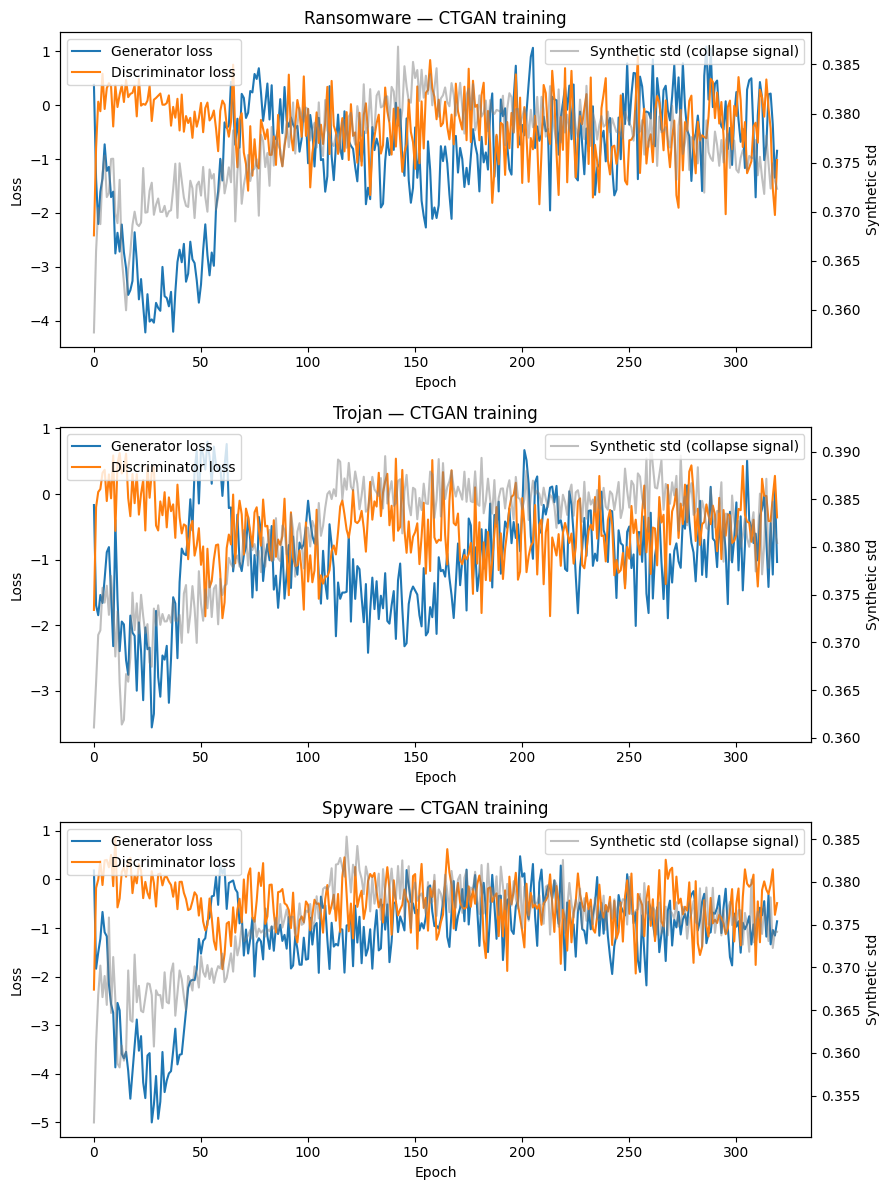

In [9]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(MINORITY_FAMILIES), 1, figsize=(9, 4 * len(MINORITY_FAMILIES)))
if len(MINORITY_FAMILIES) == 1:
    axes = [axes]

for ax, fam in zip(axes, MINORITY_FAMILIES):
    lp = log_path(fam)
    if not os.path.exists(lp):
        ax.set_title(f"{fam}: no log yet")
        continue
    log = pd.read_csv(lp)
    ax.plot(log['Epoch'], log['Generator Loss'], label='Generator loss')
    ax.plot(log['Epoch'], log['Discriminator Loss'], label='Discriminator loss')
    ax2 = ax.twinx()
    ax2.plot(log['Epoch'], log['Synthetic_Std'], color='gray', alpha=0.5, label='Synthetic std (collapse signal)')
    ax.set_title(f"{fam} — CTGAN training")
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax2.set_ylabel('Synthetic std')
    ax.legend(loc='upper left'); ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f"{WORK_DIR}/logs/ctgan_loss_curves.png", dpi=120)
plt.show()


**How to read these curves:**
- Healthy WGAN-GP training: discriminator loss hovers near 0 and generator loss slowly trends
  down/stabilizes — neither should crash to a huge magnitude and stay there.
- **Mode collapse signature:** generator loss drops sharply while `Synthetic_Std` (gray line)
  collapses toward 0 — the generator has found one output the discriminator can't easily reject
  and stopped exploring. The training loop above already prints a warning the moment this
  pattern holds for 5 straight epochs, pointing at the checkpoint saved just before it started.
- If you see collapse: load the checkpoint saved *before* the collapse streak, drop the
  generator LR (e.g. `1e-4`), and resume with `discriminator_steps=2`.


## 7. Balance every minority family up to the Benign train count (no cap)

In [10]:

def generate_balanced(fam, model, target_count):
    current_count = (train_df['Family'] == fam).sum()
    n_needed = max(target_count - current_count, 0)
    if n_needed == 0:
        print(f"[{fam}] already at/above target ({current_count} >= {target_count}), skipping.")
        return None
    print(f"[{fam}] generating {n_needed} synthetic rows "
          f"({current_count} real -> {target_count} target)")
    synth = model.sample(n_needed)
    synth = synth[FEATURE_COLS].astype(train_df[FEATURE_COLS].dtypes.to_dict())
    synth['Family'] = fam
    return synth

synthetic_frames = []
for fam in MINORITY_FAMILIES:
    if fam not in ctgan_models:
        continue
    synth = generate_balanced(fam, ctgan_models[fam], BENIGN_TRAIN_COUNT)
    if synth is not None and len(synth) > 0:
        synthetic_frames.append(synth)

synthetic_df = pd.concat(synthetic_frames, ignore_index=True) if synthetic_frames else \
    pd.DataFrame(columns=list(FEATURE_COLS) + ['Family'])
augmented_train_df = pd.concat([train_df, synthetic_df], ignore_index=True) if len(synthetic_df) else train_df.copy()

# belt-and-braces: guarantee numeric dtypes on every feature column regardless of how
# CTGAN / pandas concat typed things, since downstream classifiers (esp. XGBoost) reject
# object-dtype feature columns outright.
augmented_train_df[FEATURE_COLS] = augmented_train_df[FEATURE_COLS].apply(pd.to_numeric, errors='coerce')
augmented_train_df = augmented_train_df.dropna(subset=FEATURE_COLS)

print("\nFinal augmented training class balance:")
print(augmented_train_df['Family'].value_counts())

synthetic_df.to_csv(f"{WORK_DIR}/logs/synthetic_full_scale.csv", index=False)


[Ransomware] generating 15605 synthetic rows (7833 real -> 23438 target)
[Trojan] generating 15849 synthetic rows (7589 real -> 23438 target)
[Spyware] generating 15422 synthetic rows (8016 real -> 23438 target)

Final augmented training class balance:
Family
Benign        23438
Trojan        23438
Spyware       23438
Ransomware    23438
Name: count, dtype: int64


## 8. Quick synthetic-data quality sanity checks

In [11]:

from scipy.stats import ks_2samp

quality_rows = []
for fam in MINORITY_FAMILIES:
    real_fam = train_df[train_df['Family'] == fam]
    synth_fam = synthetic_df[synthetic_df['Family'] == fam] if len(synthetic_df) else pd.DataFrame()
    if synth_fam.empty:
        continue
    ks_stats = []
    for col in FEATURE_COLS:
        stat, _ = ks_2samp(real_fam[col], synth_fam[col])
        ks_stats.append(stat)
    quality_rows.append({
        'Family': fam,
        'mean_KS_statistic': float(np.mean(ks_stats)),
        'max_KS_statistic': float(np.max(ks_stats)),
        'n_real': len(real_fam),
        'n_synthetic': len(synth_fam),
    })

quality_df = pd.DataFrame(quality_rows)
print(quality_df)
print("\nLower KS statistic (closer to 0) = synthetic marginal distributions closer to real. "
      "Values above ~0.3 on many features suggest the CTGAN run for that class needs more "
      "epochs or a mode-collapse fix before trusting it for training.")


       Family  mean_KS_statistic  max_KS_statistic  n_real  n_synthetic
0  Ransomware           0.146960          0.716309    7833        15605
1      Trojan           0.146593          0.764654    7589        15849
2     Spyware           0.148309          0.576384    8016        15422

Lower KS statistic (closer to 0) = synthetic marginal distributions closer to real. Values above ~0.3 on many features suggest the CTGAN run for that class needs more epochs or a mode-collapse fix before trusting it for training.


## 9. Classifier benchmark for maximum accuracy

Per the Week-1 benchmarking, **Borderline-SMOTE + Random Forest** was already the strongest
classical combination. Here we compare Random Forest, XGBoost, and LightGBM trained on the
**CTGAN-augmented, fully balanced** training set, tuned with a modest `RandomizedSearchCV`
budget (kept small deliberately — Kaggle CPU time is shared with the GPU quota and a huge grid
search will eat your session).


In [12]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
# from sklearn.preprocessing import LabelEncoder
# import xgboost as xgb
# import lightgbm as lgb
# import torch

# X_train_aug = augmented_train_df[FEATURE_COLS]

# # ---------------------------------------------------------------------
# # Label Encoding
# # ---------------------------------------------------------------------
# label_encoder = LabelEncoder()

# y_train_aug = label_encoder.fit_transform(
#     augmented_train_df["Family"]
# )

# y_test_enc = label_encoder.transform(y_test)

# CLASS_NAMES = label_encoder.classes_

# # ---------------------------------------------------------------------
# # Cross Validation
# # ---------------------------------------------------------------------
# cv = StratifiedKFold(
#     n_splits=3,
#     shuffle=True,
#     random_state=42
# )

# # ---------------------------------------------------------------------
# # Candidate Models
# # ---------------------------------------------------------------------
# candidates = {

#     "RandomForest": (

#         RandomForestClassifier(
#             random_state=42,
#             n_jobs=1          # IMPORTANT: avoid nested parallelism
#         ),

#         {
#             "n_estimators": [300, 500],
#             "max_depth": [20, None],
#             "min_samples_leaf": [1, 2],
#             "max_features": ["sqrt"]
#         }
#     ),

#     "XGBoost": (

#         xgb.XGBClassifier(
#             random_state=42,
#             objective="multi:softprob",
#             eval_metric="mlogloss",
#             tree_method="hist",
#             device="cuda" if torch.cuda.is_available() else "cpu",
#             n_jobs=1
#         ),

#         {
#             "n_estimators": [300, 500],
#             "max_depth": [4, 6],
#             "learning_rate": [0.03, 0.05, 0.1],
#             "subsample": [0.8, 1.0],
#             "colsample_bytree": [0.8, 1.0]
#         }
#     ),

#     "LightGBM": (

#         lgb.LGBMClassifier(
#             random_state=42,
#             verbose=-1,
#             n_jobs=1
#         ),

#         {
#             "n_estimators": [300, 500],
#             "max_depth": [-1, 10],
#             "learning_rate": [0.03, 0.05, 0.1],
#             "num_leaves": [31, 63]
#         }
#     )
# }

# # ---------------------------------------------------------------------
# # Hyperparameter Search
# # ---------------------------------------------------------------------
# best_models = {}

# for name, (estimator, param_dist) in candidates.items():

#     if not time_budget_ok(0.30):
#         print(f"Skipping {name} tuning (time budget reached)")
#         continue

#     print("\n" + "=" * 60)
#     print(f"Tuning {name}")
#     print("=" * 60)

#     search = RandomizedSearchCV(
#         estimator=estimator,
#         param_distributions=param_dist,
#         n_iter=5,                     # Reduced from 8
#         scoring="f1_macro",
#         cv=cv,
#         random_state=42,
#         n_jobs=2,                     # Stable on Kaggle
#         pre_dispatch=2,
#         verbose=2,
#         refit=True
#     )

#     search.fit(X_train_aug, y_train_aug)

#     print(f"\n{name} Best CV Macro-F1 : {search.best_score_:.4f}")
#     print(f"{name} Best Parameters:")
#     print(search.best_params_)

#     best_models[name] = search.best_estimator_

# print("\nHyperparameter tuning completed.")

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
import torch

# ==========================================================
# Prepare Data
# ==========================================================

X_train_aug = augmented_train_df[FEATURE_COLS]

label_encoder = LabelEncoder()

y_train_aug = label_encoder.fit_transform(
    augmented_train_df["Family"]
)

y_test_enc = label_encoder.transform(y_test)

CLASS_NAMES = label_encoder.classes_

# ==========================================================
# Fixed Models (No Hyperparameter Search)
# ==========================================================

best_models = {

    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": xgb.XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        device="cuda" if torch.cuda.is_available() else "cpu",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=63,
        random_state=42,
        verbose=-1,
        n_jobs=-1
    )
}

# ==========================================================
# Train Models
# ==========================================================

for name, model in best_models.items():

    print("\n" + "=" * 60)
    print(f"Training {name}")
    print("=" * 60)

    model.fit(X_train_aug, y_train_aug)

    print(f"{name} training completed.")

print("\nAll models trained successfully.")


Training RandomForest
RandomForest training completed.

Training XGBoost
XGBoost training completed.

Training LightGBM
LightGBM training completed.

All models trained successfully.


In [13]:
# ==========================================================
# CELL 2A : Model Evaluation & Metrics
# ==========================================================

import time
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

from sklearn.preprocessing import label_binarize

# ----------------------------------------------------------
# Test Features
# ----------------------------------------------------------

X_test_final = X_test[FEATURE_COLS]

# ----------------------------------------------------------
# Containers
# ----------------------------------------------------------

results = []

predictions = {}

probabilities = {}

confusion_matrices = {}

classification_reports = {}

# Binarized labels for ROC-AUC & PR-AUC
y_test_bin = label_binarize(
    y_test_enc,
    classes=np.arange(len(CLASS_NAMES))
)

# ==========================================================
# Evaluate Every Model
# ==========================================================

for name, model in best_models.items():

    print("\n" + "="*70)
    print(f"Evaluating {name}")
    print("="*70)

    # -------------------------
    # Prediction Time
    # -------------------------

    start = time.time()

    y_pred = model.predict(X_test_final)

    inference_time = time.time() - start

    predictions[name] = y_pred

    # -------------------------
    # Prediction Probabilities
    # -------------------------

    if hasattr(model, "predict_proba"):

        y_prob = model.predict_proba(X_test_final)

    else:

        y_prob = None

    probabilities[name] = y_prob

    # -------------------------
    # Metrics
    # -------------------------

    accuracy = accuracy_score(
        y_test_enc,
        y_pred
    )

    balanced_acc = balanced_accuracy_score(
        y_test_enc,
        y_pred
    )

    precision_macro = precision_score(
        y_test_enc,
        y_pred,
        average="macro",
        zero_division=0
    )

    precision_weighted = precision_score(
        y_test_enc,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall_macro = recall_score(
        y_test_enc,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall_weighted = recall_score(
        y_test_enc,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1_macro = f1_score(
        y_test_enc,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_test_enc,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test_enc,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_test_enc,
        y_pred
    )

    # -------------------------
    # ROC-AUC & PR-AUC
    # -------------------------

    if y_prob is not None:

        roc_auc_macro = roc_auc_score(
            y_test_bin,
            y_prob,
            average="macro",
            multi_class="ovr"
        )

        roc_auc_weighted = roc_auc_score(
            y_test_bin,
            y_prob,
            average="weighted",
            multi_class="ovr"
        )

        pr_auc_macro = average_precision_score(
            y_test_bin,
            y_prob,
            average="macro"
        )

        pr_auc_weighted = average_precision_score(
            y_test_bin,
            y_prob,
            average="weighted"
        )

    else:

        roc_auc_macro = np.nan
        roc_auc_weighted = np.nan
        pr_auc_macro = np.nan
        pr_auc_weighted = np.nan

    # -------------------------
    # Confusion Matrix
    # -------------------------

    cm = confusion_matrix(
        y_test_enc,
        y_pred
    )

    confusion_matrices[name] = cm

    # -------------------------
    # Classification Report
    # -------------------------

    report = classification_report(
        y_test_enc,
        y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    classification_reports[name] = report

    # -------------------------
    # Store Results
    # -------------------------

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Balanced Accuracy": balanced_acc,

        "Precision Macro": precision_macro,

        "Precision Weighted": precision_weighted,

        "Recall Macro": recall_macro,

        "Recall Weighted": recall_weighted,

        "Macro F1": f1_macro,

        "Weighted F1": f1_weighted,

        "MCC": mcc,

        "Cohen Kappa": kappa,

        "ROC-AUC Macro": roc_auc_macro,

        "ROC-AUC Weighted": roc_auc_weighted,

        "PR-AUC Macro": pr_auc_macro,

        "PR-AUC Weighted": pr_auc_weighted,

        "Inference Time (s)": inference_time

    })

    # -------------------------
    # Print Summary
    # -------------------------

    print(f"Accuracy            : {accuracy:.4f}")
    print(f"Balanced Accuracy   : {balanced_acc:.4f}")
    print(f"Precision (Macro)   : {precision_macro:.4f}")
    print(f"Recall (Macro)      : {recall_macro:.4f}")
    print(f"Macro F1            : {f1_macro:.4f}")
    print(f"Weighted F1         : {f1_weighted:.4f}")
    print(f"MCC                 : {mcc:.4f}")
    print(f"Cohen Kappa         : {kappa:.4f}")
    print(f"ROC-AUC Macro       : {roc_auc_macro:.4f}")
    print(f"PR-AUC Macro        : {pr_auc_macro:.4f}")
    print(f"Inference Time (s)  : {inference_time:.4f}")

# ==========================================================
# Final Comparison Table
# ==========================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

print("\n")
print("="*80)
print("MODEL COMPARISON")
print("="*80)

display(results_df)


Evaluating RandomForest
Accuracy            : 0.8725
Balanced Accuracy   : 0.8083
Precision (Macro)   : 0.8081
Recall (Macro)      : 0.8083
Macro F1            : 0.8082
Weighted F1         : 0.8724
MCC                 : 0.8088
Cohen Kappa         : 0.8088
ROC-AUC Macro       : 0.9693
PR-AUC Macro        : 0.8722
Inference Time (s)  : 0.4045

Evaluating XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [11:05:05] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Accuracy            : 0.8487
Balanced Accuracy   : 0.7726
Precision (Macro)   : 0.7725
Recall (Macro)      : 0.7726
Macro F1            : 0.7725
Weighted F1         : 0.8487
MCC                 : 0.7731
Cohen Kappa         : 0.7731
ROC-AUC Macro       : 0.9605
PR-AUC Macro        : 0.8376
Inference Time (s)  : 0.1055

Evaluating LightGBM
Accuracy            : 0.8795
Balanced Accuracy   : 0.8186
Precision (Macro)   : 0.8188
Recall (Macro)      : 0.8186
Macro F1            : 0.8183
Weighted F1         : 0.8792
MCC                 : 0.8194
Cohen Kappa         : 0.8192
ROC-AUC Macro       : 0.9732
PR-AUC Macro        : 0.8875
Inference Time (s)  : 0.8865


MODEL COMPARISON


,Model,Accuracy,Balanced Accuracy,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,Macro F1,Weighted F1,MCC,Cohen Kappa,ROC-AUC Macro,ROC-AUC Weighted,PR-AUC Macro,PR-AUC Weighted,Inference Time (s)
0,LightGBM,0.879522,0.818565,0.818816,0.879304,0.818565,0.879522,0.818304,0.879153,0.819393,0.819249,0.973226,0.982206,0.887518,0.925217,0.886517
1,RandomForest,0.872526,0.808324,0.808128,0.872376,0.808324,0.872526,0.808203,0.872435,0.808788,0.808780,0.969324,0.979622,0.872155,0.915002,0.404521
2,XGBoost,0.848720,0.772608,0.772483,0.848611,0.772608,0.848720,0.772534,0.848658,0.773069,0.773064,0.960541,0.973763,0.837609,0.892042,0.105471


In [14]:
# ==========================================================
# CELL 2B : Save Reports & Detailed Evaluation
# ==========================================================

import os
import pandas as pd

SAVE_DIR = "/kaggle/working/results"
os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================================================
# Print Classification Reports
# ==========================================================

for name in best_models.keys():

    print("\n")
    print("="*80)
    print(f"{name} - Classification Report")
    print("="*80)

    print(
        classification_report(
            y_test_enc,
            predictions[name],
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0
        )
    )

# ==========================================================
# Save Classification Reports
# ==========================================================

for name in classification_reports:

    report_df = pd.DataFrame(
        classification_reports[name]
    ).transpose()

    report_df.to_csv(
        f"{SAVE_DIR}/{name}_classification_report.csv"
    )

print("Classification reports saved.")

# ==========================================================
# Save Confusion Matrices
# ==========================================================

for name in confusion_matrices:

    cm_df = pd.DataFrame(
        confusion_matrices[name],
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    )

    cm_df.to_csv(
        f"{SAVE_DIR}/{name}_confusion_matrix.csv"
    )

print("Confusion matrices saved.")

# ==========================================================
# Save Predictions
# ==========================================================

prediction_df = pd.DataFrame({

    "True_Label": label_encoder.inverse_transform(
        y_test_enc
    )

})

for name in predictions:

    prediction_df[name] = label_encoder.inverse_transform(
        predictions[name]
    )

prediction_df.to_csv(
    f"{SAVE_DIR}/model_predictions.csv",
    index=False
)

print("Predictions saved.")

# ==========================================================
# Save Prediction Probabilities
# ==========================================================

for name in probabilities:

    if probabilities[name] is None:
        continue

    prob_df = pd.DataFrame(
        probabilities[name],
        columns=CLASS_NAMES
    )

    prob_df.to_csv(
        f"{SAVE_DIR}/{name}_prediction_probabilities.csv",
        index=False
    )

print("Prediction probabilities saved.")

# ==========================================================
# Save Final Comparison Table
# ==========================================================

results_df.to_csv(
    f"{SAVE_DIR}/model_comparison.csv",
    index=False
)

print("Model comparison table saved.")

# ==========================================================
# Display Final Ranking
# ==========================================================

print("\n")
print("="*90)
print("FINAL MODEL RANKING")
print("="*90)

display(results_df)

# ==========================================================
# Best Model Summary
# ==========================================================

best_row = results_df.iloc[0]

print("\n")
print("="*90)
print("BEST MODEL")
print("="*90)

print(f"Model               : {best_row['Model']}")
print(f"Accuracy            : {best_row['Accuracy']:.4f}")
print(f"Balanced Accuracy   : {best_row['Balanced Accuracy']:.4f}")
print(f"Macro Precision     : {best_row['Precision Macro']:.4f}")
print(f"Macro Recall        : {best_row['Recall Macro']:.4f}")
print(f"Macro F1            : {best_row['Macro F1']:.4f}")
print(f"Weighted F1         : {best_row['Weighted F1']:.4f}")
print(f"MCC                 : {best_row['MCC']:.4f}")
print(f"Cohen Kappa         : {best_row['Cohen Kappa']:.4f}")
print(f"ROC-AUC Macro       : {best_row['ROC-AUC Macro']:.4f}")
print(f"PR-AUC Macro        : {best_row['PR-AUC Macro']:.4f}")

print("\n")
print("="*90)
print(f"All results saved in:\n{SAVE_DIR}")
print("="*90)



RandomForest - Classification Report
              precision    recall  f1-score   support

      Benign     1.0000    0.9998    0.9999      5860
  Ransomware     0.7302    0.7217    0.7259      1958
     Spyware     0.7842    0.7979    0.7910      2004
      Trojan     0.7181    0.7139    0.7160      1898

    accuracy                         0.8725     11720
   macro avg     0.8081    0.8083    0.8082     11720
weighted avg     0.8724    0.8725    0.8724     11720



XGBoost - Classification Report
              precision    recall  f1-score   support

      Benign     1.0000    1.0000    1.0000      5860
  Ransomware     0.6779    0.6696    0.6737      1958
     Spyware     0.7393    0.7470    0.7431      2004
      Trojan     0.6728    0.6739    0.6733      1898

    accuracy                         0.8487     11720
   macro avg     0.7725    0.7726    0.7725     11720
weighted avg     0.8486    0.8487    0.8487     11720



LightGBM - Classification Report
              precisio

,Model,Accuracy,Balanced Accuracy,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,Macro F1,Weighted F1,MCC,Cohen Kappa,ROC-AUC Macro,ROC-AUC Weighted,PR-AUC Macro,PR-AUC Weighted,Inference Time (s)
0,LightGBM,0.879522,0.818565,0.818816,0.879304,0.818565,0.879522,0.818304,0.879153,0.819393,0.819249,0.973226,0.982206,0.887518,0.925217,0.886517
1,RandomForest,0.872526,0.808324,0.808128,0.872376,0.808324,0.872526,0.808203,0.872435,0.808788,0.808780,0.969324,0.979622,0.872155,0.915002,0.404521
2,XGBoost,0.848720,0.772608,0.772483,0.848611,0.772608,0.848720,0.772534,0.848658,0.773069,0.773064,0.960541,0.973763,0.837609,0.892042,0.105471




BEST MODEL
Model               : LightGBM
Accuracy            : 0.8795
Balanced Accuracy   : 0.8186
Macro Precision     : 0.8188
Macro Recall        : 0.8186
Macro F1            : 0.8183
Weighted F1         : 0.8792
MCC                 : 0.8194
Cohen Kappa         : 0.8192
ROC-AUC Macro       : 0.9732
PR-AUC Macro        : 0.8875


All results saved in:
/kaggle/working/results


## 10. Final evaluation — 100% real, held-out test set


=== RandomForest — macro F1 on real held-out test set: 0.8082 ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.73      0.72      0.73      1958
     Spyware       0.78      0.80      0.79      2004
      Trojan       0.72      0.71      0.72      1898

    accuracy                           0.87     11720
   macro avg       0.81      0.81      0.81     11720
weighted avg       0.87      0.87      0.87     11720


=== XGBoost — macro F1 on real held-out test set: 0.7725 ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.68      0.67      0.67      1958
     Spyware       0.74      0.75      0.74      2004
      Trojan       0.67      0.67      0.67      1898

    accuracy                           0.85     11720
   macro avg       0.77      0.77      0.77     11720
weighted avg       0.85      0.85      0.85     11720




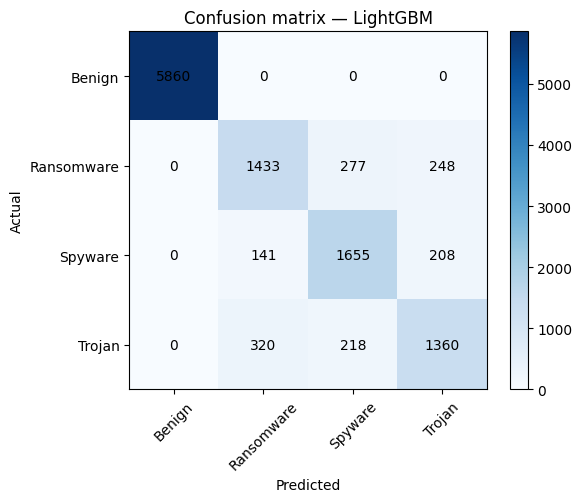

In [15]:

results = {}
for name, model in best_models.items():
    preds_enc = model.predict(X_test)
    macro_f1 = f1_score(y_test_enc, preds_enc, average='macro')
    results[name] = macro_f1
    print(f"\n=== {name} — macro F1 on real held-out test set: {macro_f1:.4f} ===")
    print(classification_report(y_test_enc, preds_enc, target_names=CLASS_NAMES))

if not results:
    print("⚠️  No classifier finished tuning before the session time budget ran out. "
          "Nothing to evaluate yet -- re-run the notebook (Section 9 onward) with more "
          "time budget available; CTGAN checkpoints from earlier sections are unaffected.")
else:
    best_name = max(results, key=results.get)
    best_model = best_models[best_name]
    print(f"\nBest model: {best_name} (macro F1 = {results[best_name]:.4f})")

    cm = confusion_matrix(y_test_enc, best_model.predict(X_test))
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap='Blues')
    plt.colorbar()
    labels = list(CLASS_NAMES)
    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.yticks(range(len(labels)), labels)
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.title(f'Confusion matrix — {best_name}')
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, cm[i, j], ha='center', va='center')
    plt.tight_layout()
    plt.savefig(f"{WORK_DIR}/logs/confusion_matrix_{best_name}.png", dpi=120)
    plt.show()


## 11. Maximizing accuracy further (things to try after this baseline run)

- **Feature selection**: drop near-zero-variance / highly correlated columns (many `psxview.*`
  and `handles.*` pairs are collinear) — often improves tree-model generalization more than it
  hurts, and speeds up tuning.
- **Threshold / class-weight tuning**: if one family (commonly `Trojan`, the hardest in Week-1
  benchmarks) lags in recall, try `class_weight='balanced'` on top of the CTGAN balancing, or
  tune per-class decision thresholds using `predict_proba`.
- **Stacking**: a small `StackingClassifier` over RandomForest + XGBoost + LightGBM with a
  logistic-regression meta-learner typically adds 0.5–1.5 macro-F1 points over the single best
  base model, at the cost of 3x inference compute — worth it if this is a research deliverable,
  not worth it if QTagger+ needs to run in real time.
- **EMBER-2018 generalization check** (already an open item in your project): retrain the final
  model's feature set against EMBER-2018's overlapping features to see if the family boundaries
  hold outside CIC-MalMem-2022 — this is also the natural place to test whether a Worm class
  transfers from another corpus, since this dataset has none.
- **More CTGAN epochs ≠ automatically better**: past the point where `Synthetic_Std` and the
  KS-statistics in Section 8 plateau, additional epochs mostly cost GPU quota. Use Section 8's
  table to decide whether a given class actually needs more than 320 epochs before spending more
  quota on it.


## 12. Save everything final

In [16]:

import joblib

if 'best_model' not in dir() or not results:
    print("Skipping save -- no best_model was produced yet (see the warning in the previous "
          "section). Re-run once a classifier finishes tuning.")
else:
    joblib.dump(best_model, f"{WORK_DIR}/models/best_classifier_{best_name}.joblib")
    augmented_train_df.to_csv(f"{WORK_DIR}/models/augmented_train_full.csv", index=False)

    with open(f"{WORK_DIR}/models/run_summary.json", 'w') as f:
        json.dump({
            'best_model': best_name,
            'macro_f1_test': results[best_name],
            'total_epochs_per_class': TOTAL_EPOCHS,
            'benign_train_count': int(BENIGN_TRAIN_COUNT),
            'families_balanced': MINORITY_FAMILIES,
            'worm_class_present': False,
            'session_hours_used': round((time.time() - SESSION_START) / 3600, 2),
        }, f, indent=2)

    print("Saved model, augmented dataset, and run summary to", f"{WORK_DIR}/models")


Saved model, augmented dataset, and run summary to /kaggle/working/models


## 13. Crash / quota-exhaustion recovery — read this first if something went wrong

**"My Kaggle session got killed / hit a CUDA OOM / ran out of the 9-12h limit."**

1. Just **re-run the notebook from the top**. Nothing needs to be manually cleaned up:
   - Section 0 re-detects the GPU and resets the session time budget.
   - Section 5's `train_or_resume()` checks `logs/loss_<family>.csv` and
     `ctgan_checkpoints/ctgan_<family>.pkl` and resumes each class from its last completed
     epoch — it will not retrain from scratch.
   - Sections 7 onward simply re-run against whatever models exist at that point; if a class
     hasn't finished its 320 epochs yet, its synthetic contribution will reflect training so far
     (check the Section 8 KS table before trusting an under-trained class in the final model).
2. **CUDA out-of-memory during CTGAN training**: lower `BATCH_SIZE` in Section 5 (try 250, then
   128) and re-run — checkpoints already saved are unaffected by this change.
3. **Weekly GPU quota exhausted**: everything on disk in `/kaggle/working` survives; wait for the
   quota reset (or switch to a CPU session to at least run the classifier-tuning cells, which
   don't need GPU) and resume next week.
4. **You want a completely clean restart** (e.g. you changed `TOTAL_EPOCHS` or the feature set):
   delete the relevant files under `ctgan_checkpoints/` and `logs/` for the classes you want to
   redo, then re-run.
